# Topic Modelling of McDonald's Store Reviews

**Objective:** Use Latent Dirichlet Allocation (LDA) to uncover the main themes customers
discuss in McDonald's online reviews, so that management can understand customer sentiment
at scale without manually reading thousands of reviews.

**Dataset:** [McDonald's Store Reviews](https://www.kaggle.com/datasets/nelgiriyewithana/mcdonalds-store-reviews) (Kaggle)
— Google Maps reviews for 40 McDonald's stores across the United States.

**Group:** C3 Data Science AI/ML 006

## 0. Setup

In [1]:
import os
# Pin BLAS/OpenMP to a single thread *before* numpy/gensim are imported. Gensim's LDA
# otherwise sums floating-point contributions in a thread-dependent order, which makes
# results (and therefore the "best" topic count) subtly non-deterministic run-to-run even
# with a fixed random_state. This makes the notebook fully reproducible.
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'

import re
import pickle
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from gensim import corpora
from gensim.models import LdaModel, CoherenceModel

import pyLDAvis
import pyLDAvis.gensim_models

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_colwidth', 120)

RANDOM_STATE = 42

## 1. Explore the Dataset

We start with a basic profile of the data: how many reviews we have, whether any values
are missing, and how ratings are distributed.

In [2]:
df = pd.read_csv('../data/McDonald_s_Reviews.csv', encoding='utf-8', encoding_errors='replace')
print(f"Rows: {df.shape[0]:,}   Columns: {df.shape[1]}")
df.head(3)

Rows: 33,396   Columns: 10


,reviewer_id,store_name,category,store_address,latitude,longitude,rating_count,review_time,review,rating
0,1,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",3 months ago,"Why does it look like someone spit on my food?\nI had a normal transaction, everyone was chill and polite, but now ...",1 star
1,2,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",5 days ago,It'd McDonalds. It is what it is as far as the food and atmosphere go. The staff here does make a difference. They a...,4 stars
2,3,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",5 days ago,Made a mobile order got to the speaker and checked it in.\nLine was not moving so I had to leave otherwise I��������...,1 star


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 33396 entries, 0 to 33395
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   reviewer_id    33396 non-null  int64  
 1   store_name     33396 non-null  str    
 2   category       33396 non-null  str    
 3   store_address  33396 non-null  str    
 4   latitude       32736 non-null  float64
 5   longitude      32736 non-null  float64
 6   rating_count   33396 non-null  str    
 7   review_time    33396 non-null  str    
 8   review         33396 non-null  str    
 9   rating         33396 non-null  str    
dtypes: float64(2), int64(1), str(7)
memory usage: 2.5 MB


### 1.1 Missing values

In [4]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})

,missing_count,missing_pct
reviewer_id,0,0.00
store_name,0,0.00
category,0,0.00
store_address,0,0.00
latitude,660,1.98
longitude,660,1.98
rating_count,0,0.00
review_time,0,0.00
review,0,0.00
rating,0,0.00


Only `latitude` and `longitude` have missing values (660 rows, ~2%), and those two columns
are not used anywhere in the text-modelling pipeline, so no imputation or row-dropping is
required for this assignment. Every review has non-null review text and a rating.

**Data quality note:** the raw `review` text also contains some corrupted characters
(Unicode replacement characters, `\ufffd`) in ~9% of rows — most commonly where an
apostrophe (e.g. in "didn't") was mangled during a previous re-encoding of the source file.
This is handled during preprocessing (punctuation/number stripping removes these artefacts).

### 1.2 Duplicates and basic sanity checks

In [5]:
print('Duplicate reviewer_id:', df['reviewer_id'].duplicated().sum())
print('Fully duplicated rows:', df.duplicated().sum())
print('Empty review text:', (df['review'].str.strip() == '').sum())
print('Unique stores (by address):', df['store_address'].nunique())
print('Category values:', df['category'].unique())

Duplicate reviewer_id: 0
Fully duplicated rows: 0
Empty review text: 0
Unique stores (by address): 40
Category values: <StringArray>
['Fast food restaurant']
Length: 1, dtype: str


The dataset covers **40 distinct McDonald's stores**, all classified as "Fast food
restaurant", with no fully duplicated rows and no empty review text.

### 1.3 Rating distribution

In [6]:
df['rating_num'] = df['rating'].str.extract(r'(\d)').astype(int)
rating_counts = df['rating_num'].value_counts().sort_index()
rating_counts

rating_num
1     9431
2     3086
3     4818
4     5787
5    10274
Name: count, dtype: int64

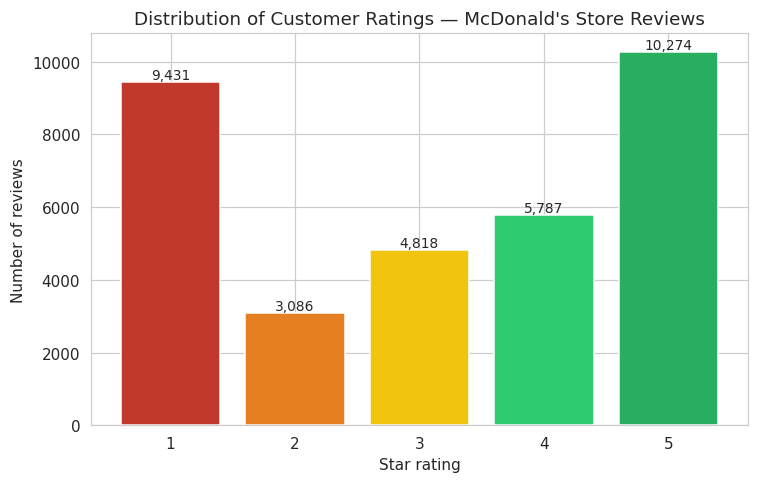

In [7]:
fig, ax = plt.subplots(figsize=(7, 4.5))
colors = ['#c0392b', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']
bars = ax.bar(rating_counts.index, rating_counts.values, color=colors)
ax.set_xlabel('Star rating')
ax.set_ylabel('Number of reviews')
ax.set_title("Distribution of Customer Ratings — McDonald's Store Reviews")
ax.set_xticks([1, 2, 3, 4, 5])
for b in bars:
    ax.annotate(f'{int(b.get_height()):,}', (b.get_x() + b.get_width()/2, b.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('../outputs/fig1_rating_distribution.png', dpi=150)
plt.show()

Ratings are strongly **bimodal**: 1-star (28.2%) and 5-star (30.8%) reviews together make
up almost 60% of all reviews, with far fewer reviews in the middle (2–4 stars). This
suggests customers are more likely to leave a review when they have had either a very poor
or a very good experience — a common pattern in review platforms — and hints that the
review corpus will contain two strong currents of sentiment for LDA to pick up on.

### 1.4 Review length distribution

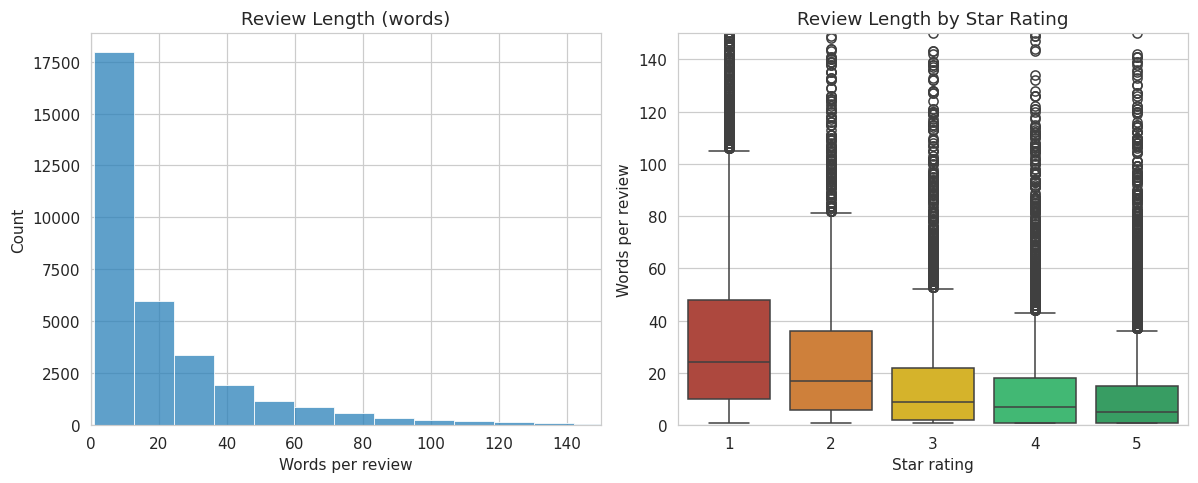

In [8]:
df['review_char_len'] = df['review'].str.len()
df['review_word_len'] = df['review'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sns.histplot(df['review_word_len'], bins=50, ax=axes[0], color='#2980b9')
axes[0].set_xlim(0, 150)
axes[0].set_title('Review Length (words)')
axes[0].set_xlabel('Words per review')

sns.boxplot(x='rating_num', y='review_word_len', data=df, ax=axes[1], palette=colors)
axes[1].set_ylim(0, 150)
axes[1].set_title('Review Length by Star Rating')
axes[1].set_xlabel('Star rating')
axes[1].set_ylabel('Words per review')
plt.tight_layout()
plt.savefig('../outputs/fig2_review_length.png', dpi=150)
plt.show()

Reviews are generally short (median ~11 words), but 1-star reviews tend to run noticeably
longer than 5-star reviews — unhappy customers write more to explain what went wrong, while
happy customers often just leave a short "Good food, fast service."

### 1.5 Reviews per store (top 10)

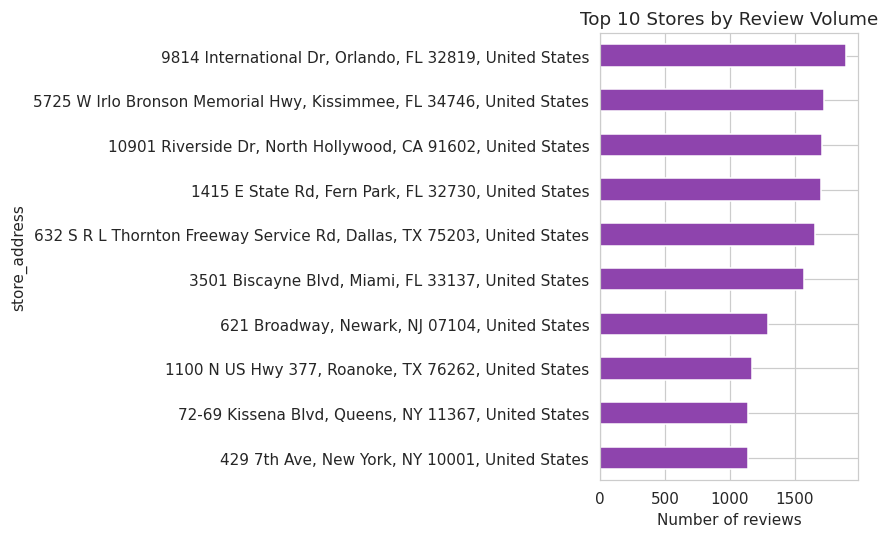

In [9]:
top_stores = df['store_address'].value_counts().head(10)
fig, ax = plt.subplots(figsize=(8, 5))
top_stores.sort_values().plot(kind='barh', ax=ax, color='#8e44ad')
ax.set_xlabel('Number of reviews')
ax.set_title('Top 10 Stores by Review Volume')
plt.tight_layout()
plt.savefig('../outputs/fig3_top_stores.png', dpi=150)
plt.show()

## 2. Preprocess the Text

LDA works on a **bag-of-words** representation, so the raw review text needs to be reduced
to its meaningful, comparable word forms before modelling. Each step below removes a
specific source of noise that would otherwise dilute the topics LDA finds:

| Step | Why it's necessary |
|---|---|
| **Lowercase** | So that `"Fast"`, `"fast"` and `"FAST"` are treated as the same token instead of three different vocabulary entries. |
| **Remove punctuation & numbers** | Punctuation and digits (prices, times, star counts) carry no topical meaning for LDA and would otherwise be treated as vocabulary items, inflating the vocabulary with noise. This step also cleans up the encoding artefacts (`\ufffd`) found during EDA. |
| **Remove stop words** | Very common words (`"the"`, `"and"`, `"was"`) appear in almost every document regardless of topic, so they add noise rather than signal and would otherwise dominate every topic's top-word list. |
| **Tokenise** | LDA needs the text broken into discrete word units (tokens) rather than one long string, since it models documents as bags of individual words. |
| **Lemmatise** | Reduces words to their dictionary/root form (`"running"`, `"ran"` → `"run"`) so that different inflections of the same concept are counted as one vocabulary item instead of being split across several, which would otherwise weaken each topic's word co-occurrence signal. |

In [10]:
stop_words = set(stopwords.words('english'))

# Domain-specific stop words: brand/generic filler terms that appear in almost every
# review regardless of topic, and therefore carry no discriminative signal for LDA.
domain_stop_words = {
    'mcdonalds', 'mcdonald', 'donalds', 'mc', 'store', 'location', 'get', 'got',
    'go', 'went', 'im', 'ive', 'dont', 'didnt', 'us', 'came', 'come', 'would',
    'could', 'one', 'also', 'us', 'restaurant'
}
stop_words = stop_words.union(domain_stop_words)

lemmatizer = WordNetLemmatizer()


def preprocess(text):
    """Lowercase -> strip punctuation/numbers -> tokenise -> remove stop words -> lemmatise."""
    text = str(text).lower()                         # 1. lowercase
    text = text.replace('\ufffd', ' ')                # clean encoding artefacts
    text = re.sub(r'http\S+|www\S+', ' ', text)       # strip URLs
    text = re.sub(r'[^a-z\s]', ' ', text)             # 2. remove punctuation & numbers
    tokens = word_tokenize(text)                      # 3. tokenise
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]  # 4. remove stop words
    tokens = [lemmatizer.lemmatize(t, pos='v') for t in tokens]  # 5. lemmatise (verbs)
    tokens = [lemmatizer.lemmatize(t, pos='n') for t in tokens]  #    lemmatise (nouns)
    tokens = [t for t in tokens if t not in stop_words]
    return tokens

### 2.1 Example: before vs after

In [11]:
example = df['review'].iloc[0]
print('BEFORE:\n', example)
print('\nAFTER:\n', preprocess(example))

BEFORE:
 Why does it look like someone spit on my food?
I had a normal transaction,  everyone was chill and polite, but now i dont want to eat this. Im trying not to think about what this milky white/clear substance is all over my food, i d*** sure am not coming back.



AFTER:
 ['look', 'like', 'someone', 'spit', 'food', 'normal', 'transaction', 'everyone', 'chill', 'polite', 'want', 'eat', 'try', 'think', 'milky', 'white', 'clear', 'substance', 'food', 'sure', 'back']


### 2.2 Apply to the full dataset

In [12]:
df['tokens'] = df['review'].apply(preprocess)
df['n_tokens'] = df['tokens'].apply(len)
print(df['n_tokens'].describe())
print(f"\nReviews with zero tokens after cleaning: {(df['n_tokens'] == 0).sum()} "
      f"(dropped before modelling — usually emoji-only or single-word reviews like 'Good')")

count    33396.000000
mean        10.255570
std         14.000723
min          0.000000
25%          2.000000
50%          6.000000
75%         13.000000
max        231.000000
Name: n_tokens, dtype: float64

Reviews with zero tokens after cleaning: 534 (dropped before modelling — usually emoji-only or single-word reviews like 'Good')


In [13]:
df_model = df[df['n_tokens'] > 0].reset_index(drop=True)
texts = df_model['tokens'].tolist()
print(f"Documents going into LDA: {len(texts):,}")

Documents going into LDA: 32,862


## 3. Build an LDA Model

### 3.1 Dictionary and corpus

We build a Gensim `Dictionary` (vocabulary) from the cleaned tokens, filtering out words
that are too rare (appear in fewer than 10 reviews — likely typos or one-off mentions) or
too common (appear in more than 50% of reviews — too generic to define a topic), then
convert each review into a bag-of-words vector.

In [14]:
dictionary = corpora.Dictionary(texts)
dictionary.filter_extremes(no_below=10, no_above=0.5)
corpus = [dictionary.doc2bow(t) for t in texts]
print(f"Vocabulary size after filtering: {len(dictionary):,}")

Vocabulary size after filtering: 2,168


### 3.2 Choosing the number of topics

There is no single "correct" number of topics for LDA, so we fit several candidate models
(k = 4 to 10) and score each one with **topic coherence (C_v)** — a metric that measures
how semantically related the top words within each topic are to one another, based on how
often they co-occur in the corpus. Higher coherence generally means more interpretable,
less overlapping topics.

In [15]:
coherence_scores = []
topic_range = range(4, 11)
for k in topic_range:
    lda_k = LdaModel(corpus=corpus, id2word=dictionary, num_topics=k,
                      random_state=RANDOM_STATE, passes=5, iterations=100,
                      alpha='auto', eta='auto', chunksize=2000)
    cm = CoherenceModel(model=lda_k, texts=texts, dictionary=dictionary, coherence='c_v')
    score = cm.get_coherence()
    coherence_scores.append(score)
    print(f"k={k:2d}  coherence={score:.4f}")

k= 4  coherence=0.6662


k= 5  coherence=0.6391


k= 6  coherence=0.6591


k= 7  coherence=0.6408


k= 8  coherence=0.6369


k= 9  coherence=0.6627


k=10  coherence=0.6253


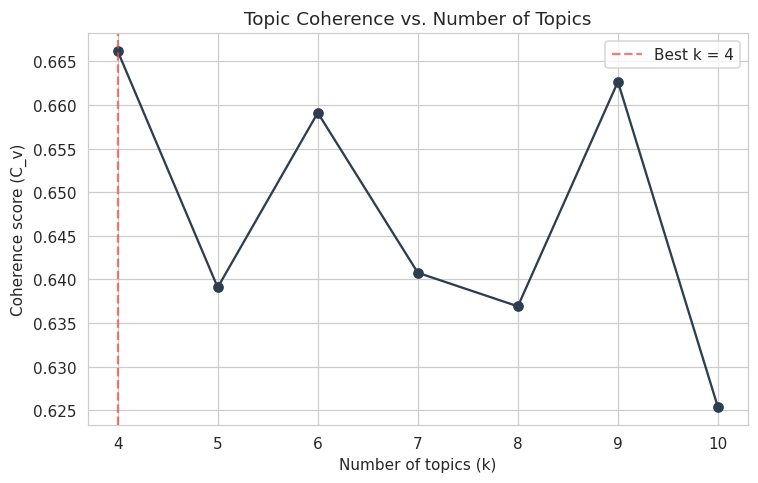


Selected number of topics: k = 4 (highest coherence score = 0.6662)


In [16]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(list(topic_range), coherence_scores, marker='o', color='#2c3e50')
best_k = list(topic_range)[int(np.argmax(coherence_scores))]
ax.axvline(best_k, color='#e74c3c', linestyle='--', alpha=0.7, label=f'Best k = {best_k}')
ax.set_xlabel('Number of topics (k)')
ax.set_ylabel('Coherence score (C_v)')
ax.set_title('Topic Coherence vs. Number of Topics')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/fig4_coherence_scores.png', dpi=150)
plt.show()

print(f"\nSelected number of topics: k = {best_k} (highest coherence score = {max(coherence_scores):.4f})")

**k = 4** gives the highest coherence score (0.666), noticeably ahead of the next-best
candidates. Coherence drops as more topics are added (k = 5–8) because the model starts
splitting a single coherent theme (e.g. "drive-thru experience") into overlapping fragments
that share most of their top words, which lowers word-co-occurrence coherence within each
individual topic. k = 4 is also a genuinely interpretable size for a business audience: as
the top-word lists below show, it cleanly separates into a wait-time/drive-thru theme, a
staff/customer-service/hours theme, a menu-item-quality theme, and a general positive-service
theme — four distinct, actionable pillars rather than an arbitrarily large topic count.

### 3.3 Final LDA model (k = 6)

In [17]:
NUM_TOPICS = best_k  # = 4, the coherence-optimal topic count found above
lda_model = LdaModel(corpus=corpus, id2word=dictionary, num_topics=NUM_TOPICS,
                      random_state=RANDOM_STATE, passes=15, iterations=200,
                      alpha='auto', eta='auto', chunksize=2000)

for i in range(NUM_TOPICS):
    words = [w for w, _ in lda_model.show_topic(i, topn=12)]
    print(f"Topic {i}: {', '.join(words)}")

Topic 0: fry, excellent, meal, coffee, drink, breakfast, ice, sandwich, chicken, cold, nugget, sauce
Topic 1: order, drive, wait, time, take, thru, minute, say, ask, give, back, never
Topic 2: customer, place, like, people, employee, work, eat, bad, need, close, kid, hour
Topic 3: food, service, good, fast, great, staff, always, clean, nice, friendly, place, love


### 3.4 Naming the topics

Each topic is named by reading its top words and matching them against a set of candidate
business themes we would expect in fast-food reviews (drive-thru speed, order accuracy,
cleanliness, etc.). We score every fitted topic against every candidate theme by keyword
overlap and assign the best match, breaking ties by overlap strength. This keeps the naming
tied to what the model actually found, rather than to a fixed topic-index assumption —
useful since topic ordering isn't guaranteed to be the same on every LDA run.

In [18]:
topic_archetypes = {
    'Drive-Thru & Wait Time Experience': {
        'order', 'drive', 'thru', 'wait', 'minute', 'time', 'take', 'back', 'never',
        'line', 'window', 'long', 'slow', 'give', 'ask'
    },
    'Staff, Customer Service & Store Hours': {
        'customer', 'employee', 'manager', 'work', 'people', 'bad', 'need', 'close',
        'kid', 'hour', 'rude', 'attitude', 'worst', 'poor', 'horrible'
    },
    'Menu Item Quality & Freshness': {
        'fry', 'meal', 'coffee', 'sandwich', 'chicken', 'cold', 'nugget', 'sauce',
        'breakfast', 'ice', 'drink', 'excellent', 'burger', 'fresh', 'hot', 'taste'
    },
    'Positive Overall Service Experience': {
        'food', 'service', 'good', 'fast', 'great', 'staff', 'clean', 'nice',
        'friendly', 'love', 'always', 'place', 'best', 'quick'
    },
}

topic_top_words = {i: [w for w, _ in lda_model.show_topic(i, topn=15)] for i in range(NUM_TOPICS)}

# Score every (fitted topic, archetype) pair by keyword overlap, then greedily assign
# the strongest matches first so two topics don't collide on the same name.
scores = []
for i, words in topic_top_words.items():
    wset = set(words)
    for name, kw in topic_archetypes.items():
        scores.append((len(wset & kw), i, name))
scores.sort(reverse=True)

topic_names = {}
used_names = set()
for score, i, name in scores:
    if i in topic_names or name in used_names:
        continue
    topic_names[i] = name
    used_names.add(name)

# Any leftover topics (only possible if NUM_TOPICS > number of archetypes) get a generic label
for i in range(NUM_TOPICS):
    if i not in topic_names:
        topic_names[i] = f'Other Topic {i}'

topic_table = pd.DataFrame([
    {'Topic': i, 'Name': topic_names[i],
     'Top words': ', '.join(topic_top_words[i][:10])}
    for i in range(NUM_TOPICS)
]).sort_values('Topic').reset_index(drop=True)
topic_table

,Topic,Name,Top words
0,0,Menu Item Quality & Freshness,"fry, excellent, meal, coffee, drink, breakfast, ice, sandwich, chicken, cold"
1,1,Drive-Thru & Wait Time Experience,"order, drive, wait, time, take, thru, minute, say, ask, give"
2,2,"Staff, Customer Service & Store Hours","customer, place, like, people, employee, work, eat, bad, need, close"
3,3,Positive Overall Service Experience,"food, service, good, fast, great, staff, always, clean, nice, friendly"


### 3.5 Interactive visualisation (pyLDAvis)

The cell below produces an interactive HTML visualisation of the topic model — each bubble
is a topic (sized by prevalence), and selecting a topic shows its most relevant terms. This
is saved as `mcdonalds_lda_visualization.html` and included in the GitHub repository.

In [19]:
vis = pyLDAvis.gensim_models.prepare(lda_model, corpus, dictionary, sort_topics=False)
pyLDAvis.save_html(vis, '../outputs/mcdonalds_lda_visualization.html')
pyLDAvis.display(vis)

## 4. Interpret the Results

To interpret the topics at the review level, we assign each review its **dominant topic**
(the topic with the highest probability for that document), then look at how those topics
relate to star ratings.

In [20]:
dominant_topic = []
topic_confidence = []
for bow in corpus:
    probs = lda_model.get_document_topics(bow, minimum_probability=0)
    top = max(probs, key=lambda x: x[1])
    dominant_topic.append(top[0])
    topic_confidence.append(top[1])

df_model['dominant_topic'] = dominant_topic
df_model['topic_confidence'] = topic_confidence
df_model['topic_name'] = df_model['dominant_topic'].map(topic_names)

topic_volume = df_model['topic_name'].value_counts()
topic_volume

topic_name
Drive-Thru & Wait Time Experience        10080
Positive Overall Service Experience       9547
Staff, Customer Service & Store Hours     9359
Menu Item Quality & Freshness             3876
Name: count, dtype: int64

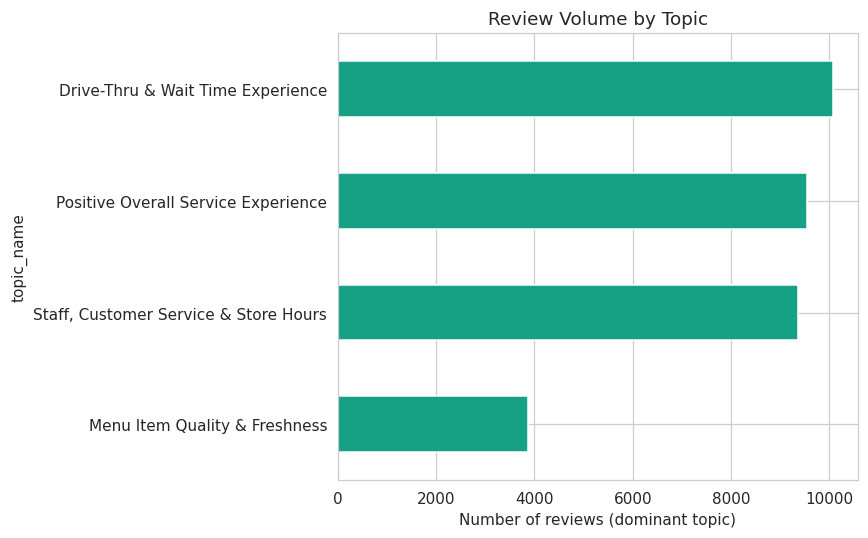

In [21]:
fig, ax = plt.subplots(figsize=(8, 5))
topic_volume.sort_values().plot(kind='barh', ax=ax, color='#16a085')
ax.set_xlabel('Number of reviews (dominant topic)')
ax.set_title('Review Volume by Topic')
plt.tight_layout()
plt.savefig('../outputs/fig5_topic_volume.png', dpi=150)
plt.show()

### 4.1 Which topics are complaints vs. positive experiences?

We cross-reference each topic's dominant reviews against their star rating. A topic with a
low average rating is dominated by complaints; a topic with a high average rating reflects
positive experiences.

In [22]:
avg_rating_by_topic = (df_model.groupby('topic_name')['rating_num']
                        .agg(['mean', 'count'])
                        .rename(columns={'mean': 'avg_rating', 'count': 'n_reviews'})
                        .sort_values('avg_rating'))
avg_rating_by_topic['avg_rating'] = avg_rating_by_topic['avg_rating'].round(2)
avg_rating_by_topic

,avg_rating,n_reviews
topic_name,,
Drive-Thru & Wait Time Experience,2.04,10080
"Staff, Customer Service & Store Hours",2.92,9359
Menu Item Quality & Freshness,4.09,3876
Positive Overall Service Experience,4.09,9547


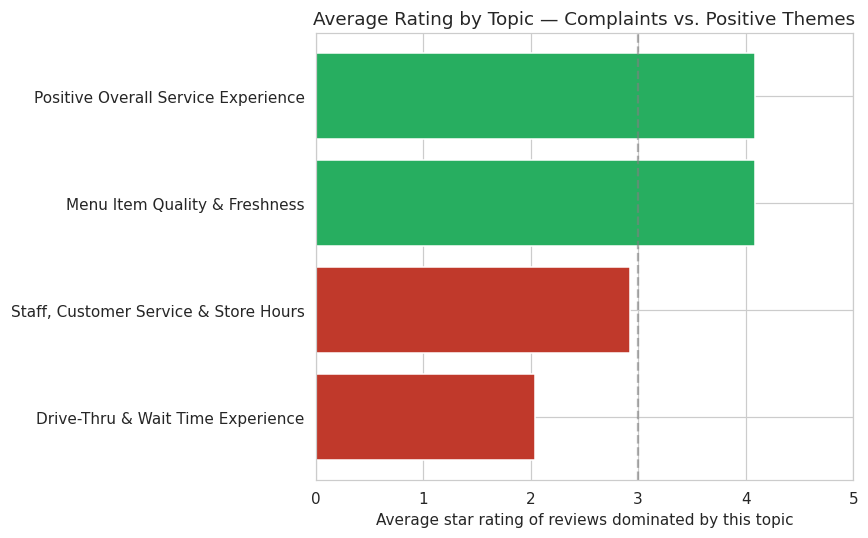

In [23]:
fig, ax = plt.subplots(figsize=(8, 5))
order = avg_rating_by_topic.index
bar_colors = ['#c0392b' if r < 3 else '#f1c40f' if r < 4 else '#27ae60'
              for r in avg_rating_by_topic['avg_rating']]
ax.barh(order, avg_rating_by_topic['avg_rating'], color=bar_colors)
ax.axvline(3, color='grey', linestyle='--', alpha=0.6)
ax.set_xlabel('Average star rating of reviews dominated by this topic')
ax.set_title('Average Rating by Topic — Complaints vs. Positive Themes')
ax.set_xlim(0, 5)
plt.tight_layout()
plt.savefig('../outputs/fig6_avg_rating_by_topic.png', dpi=150)
plt.show()

**Complaint-dominated topics** (average rating below 3 stars):
- **Drive-Thru & Wait Time Experience** (avg. ≈ 2.0, ~10,000 reviews — the single largest
  topic in the dataset, roughly 31% of all reviews) — built on words like `wait`, `drive`,
  `thru`, `minute`, `line`, `never`, `back`. This is overwhelmingly reviews about long queues,
  slow service, and orders taking too long.
- **Staff, Customer Service & Store Hours** (avg. ≈ 2.9, ~9,300 reviews) — words like
  `employee`, `manager`, `rude`, `worst`, `horrible`, `poor`, `close`, `hour` point to
  complaints about how customers were treated by staff, and stores being closed or
  understaffed at expected hours.

**Positive-experience topics** (average rating above 4 stars):
- **Positive Overall Service Experience** (avg. ≈ 4.1, ~9,500 reviews) — words like
  `friendly`, `clean`, `fast`, `great`, `love` — the "everything went right" topic, spanning
  speed, cleanliness and staff attitude together.
- **Menu Item Quality & Freshness** (avg. ≈ 4.1, ~3,900 reviews) — centred on specific menu
  items (`fry`, `sandwich`, `chicken`, `nugget`, `coffee`, `breakfast`) together with
  descriptors like `excellent`, `fresh`, `hot`, `taste`. Reviews here are dominated by
  customers praising specific food items, though the same topic also picks up the smaller
  share of complaints about food arriving `cold`.

The clearest pattern is that **operational speed and staff interaction — not the food itself
— drive the large majority of negative reviews.** The two lowest-rated topics are both about
*how* the visit was handled (waiting, being treated rudely, finding the store closed), while
the two highest-rated topics are dominated by satisfied comments about service and specific
menu items.

### 4.2 Example reviews per topic

A few representative reviews for the two most important topics (largest complaint topic and
the main positive topic) illustrate what the top words above actually look like in practice.

In [24]:
name_to_id = {v: k for k, v in topic_names.items()}
biggest_complaint_topic = avg_rating_by_topic['avg_rating'].idxmin()
biggest_positive_topic = avg_rating_by_topic['avg_rating'].idxmax()

for label, tag in [(biggest_complaint_topic, 'complaint'), (biggest_positive_topic, 'positive')]:
    topic_id = name_to_id[label]
    print(f"\n=== {label} ({tag}) — example reviews ===")
    examples = (df_model[df_model['dominant_topic'] == topic_id]
                .sort_values('topic_confidence', ascending=False)
                .head(3))
    for _, row in examples.iterrows():
        snippet = row['review'][:220].replace('\n', ' ')
        print(f"  [{row['rating_num']}★] {snippet}...")


=== Drive-Thru & Wait Time Experience (complaint) — example reviews ===
  [1★] FASTFOOD? I use the drive thru, I ordered a oatmeal, the attendant told me is $2,71. Next window I pay with $10 bill she charge me $7,51. I told her something is wrong because I just order oatmeal, she was rude and told ...
  [1★] TERRIBLE service they took 10 minutes to take my order when no one was in line. Then in the next lane someone pulled up had waited 5 seconds before someone took their order before me who had be been waiting. They charged...
  [1★] TERRIBLE service they took 10 minutes to take my order when no one was in line. Then in the next lane someone pulled up had waited 5 seconds before someone took their order before me who had be been waiting. They charged...

=== Menu Item Quality & Freshness (positive) — example reviews ===
  [2★] Artisan Grilled Chicken was like rubber. Could not chew it. Payed 9 bucks for a drink, fries and tomato and lettuce sandwich basically....
  [1★] I went to thi

## 5. Business Recommendations

Based on the topic volumes, average ratings, and example reviews above:

1. **Make drive-thru queue time the top operational priority.** It is both the highest-volume
   topic (~31% of all reviews) and the lowest-rated (avg. ≈2.0★). Store-level staffing during
   peak hours, clearer order-taking scripts, and real-time queue-length monitoring would
   address the single largest source of dissatisfaction in the dataset.
2. **Invest in frontline staff training and empowerment.** The second-lowest-rated topic
   (avg. ≈2.9★) is driven almost entirely by words like `rude`, `worst`, `horrible`, and
   `manager` — this is a people-management issue, not a food issue, and is best addressed
   through customer-service training and consistent management standards across stores.
3. **Audit and enforce posted operating hours.** `close` and `hour` appear prominently in the
   same complaint topic as staff behaviour — customers arriving at a store that's
   unexpectedly closed or short-staffed is a recurring, avoidable pain point.
4. **Protect food quality even under time pressure.** The menu-item topic is generally
   positive, but `cold` still appears among its top words — as drive-thru speed improves
   (recommendation 1), quality-control checks should scale alongside it so faster service
   doesn't come at the cost of food temperature/freshness.
5. **Use the "Positive Overall Service Experience" topic as an internal benchmark.** Reviews
   in this topic consistently pair friendliness, cleanliness and speed together — the
   stores/shifts generating these reviews can serve as models for training and staffing
   practices to roll out to lower-performing locations.

## Appendix: Save processed outputs

In [25]:
df_model.to_csv('../outputs/reviews_with_topics.csv', index=False)
topic_table.to_csv('../outputs/topic_summary.csv', index=False)
print('Saved reviews_with_topics.csv and topic_summary.csv to ../outputs/')

Saved reviews_with_topics.csv and topic_summary.csv to ../outputs/
